### **1. Introduction**

This notebook provides an explainable analysis of soil zones generated using three unsupervised clustering techniques:

1. **K-Means**

2. **Agglomerative Clustering**

3. **Gaussian Mixture Models (GMM)**

Because clustering is unsupervised and does not learn explicit decision rules, explainability is achieved using post-hoc XAI techniques. The goal is not prediction, but understanding what defines each soil zone, how stable the clusters are, and whether different clustering paradigms lead to consistent interpretations.

### **2. Load Clustered Dataset**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import learning_curve, validation_curve

import shap

import json

sns.set_style("whitegrid")

df = pd.read_csv("../outputs/soil_clusters_top_3_models.csv")

FEATURES = ["taw", "organic_carbon", "cec", "ph", "sand_pct"]

CLUSTER_MODELS = {
    "K-Means": "cluster_kmeans",
    "Agglomerative": "cluster_agg",
    "GMM": "cluster_gmm"
}

print("Samples:", len(df))

Samples: 3422


### **3. Scale Features for Interpretability**

In [16]:
import joblib

scaler = joblib.load("../outputs/soil_scaler.pkl")
X_scaled = scaler.transform(df[FEATURES])
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)

The saved scaler is loaded here rather than fitting a new one. This makes sure the centroid deviation analysis is computed in the same standardized space that was used during clustering, making the deviations directly interpretable relative to the actual cluster boundaries.

### **4. Centroid Deviation**

#### **Compute Deviations**

In [17]:
global_mean = X_scaled_df.mean()

deviations = {}

for model, col in CLUSTER_MODELS.items():
    cluster_means = X_scaled_df.groupby(df[col]).mean()
    deviations[model] = cluster_means - global_mean

#### **Visualize Cluster Characteristics**

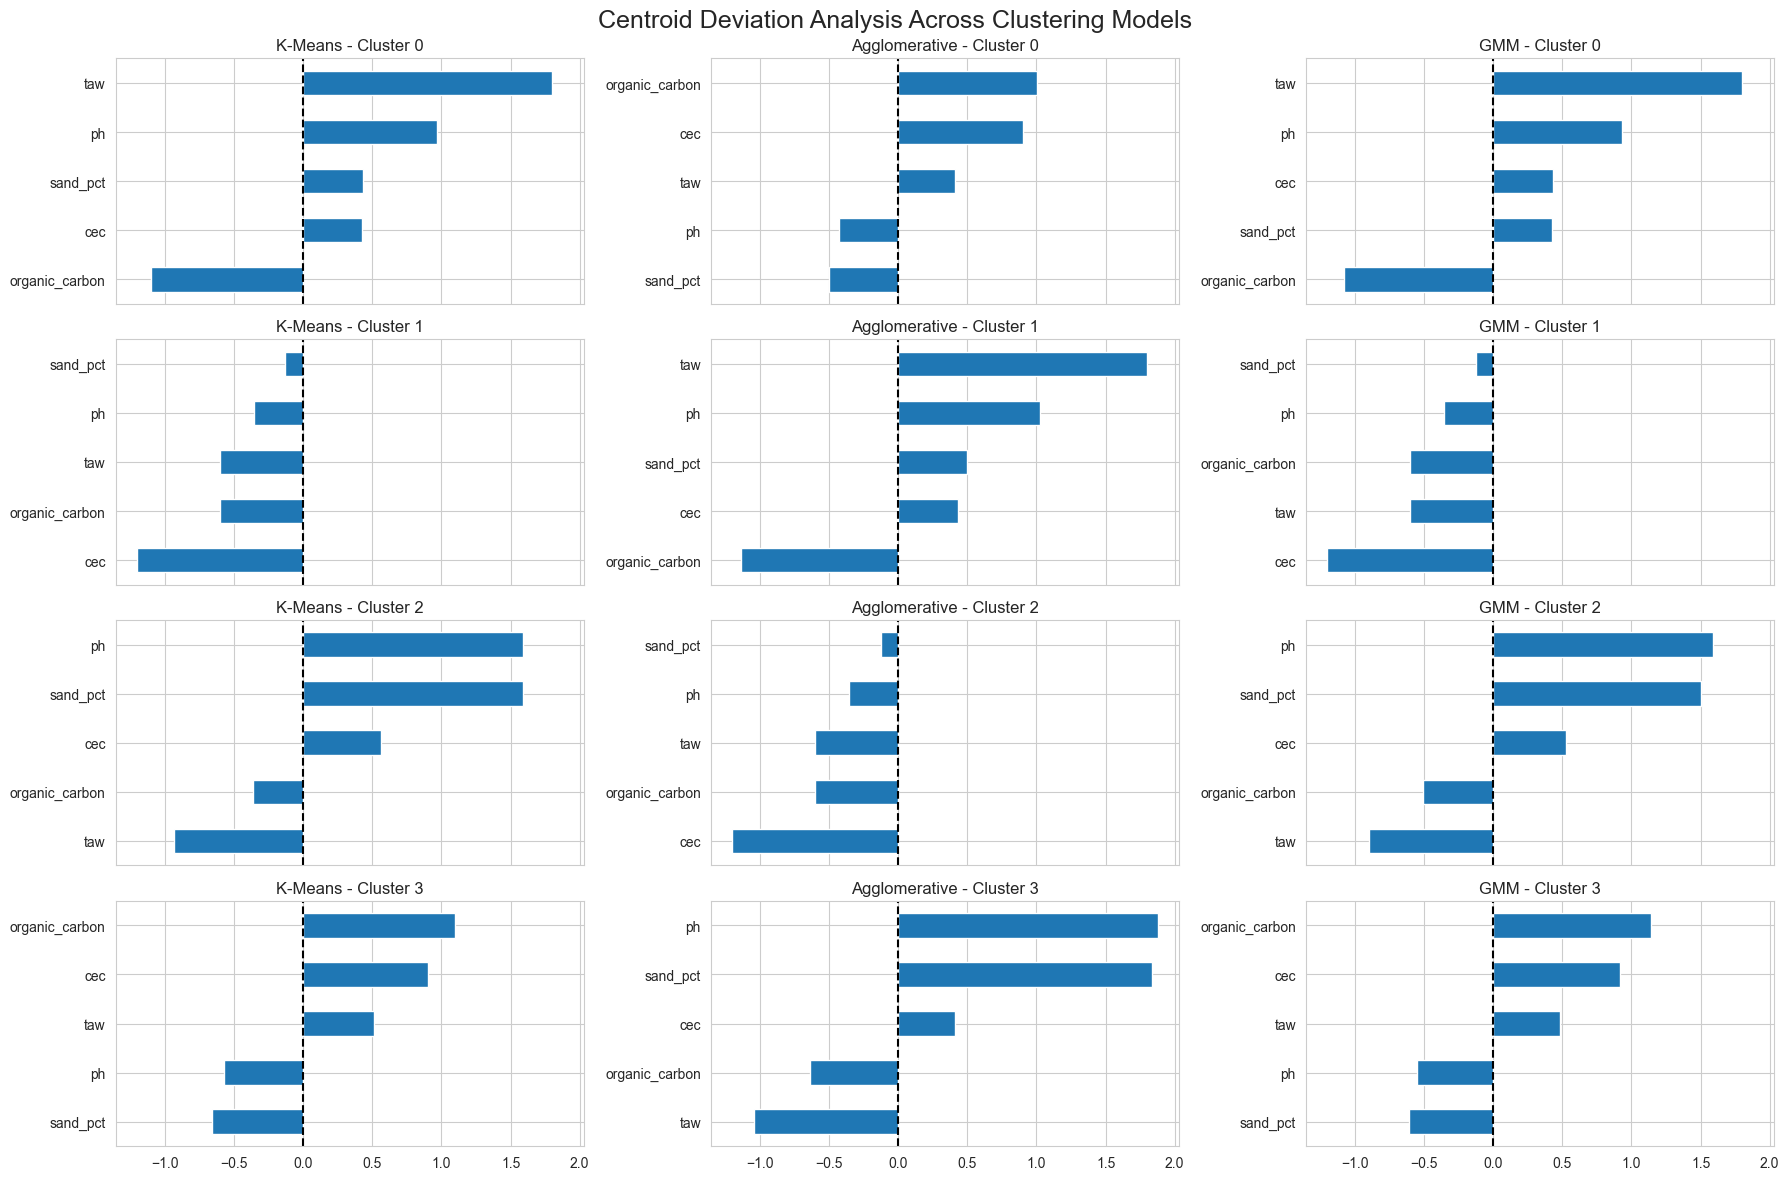

In [18]:
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True)

for col_idx, (model, dev) in enumerate(deviations.items()):
    for row_idx, cluster_id in enumerate(dev.index):
        ax = axes[row_idx, col_idx]
        dev.loc[cluster_id].sort_values().plot.barh(ax=ax)
        ax.axvline(0, color="black", linestyle="--")
        ax.set_title(f"{model} - Cluster {cluster_id}")

plt.suptitle("Centroid Deviation Analysis Across Clustering Models", fontsize=18)
plt.tight_layout()
plt.show()

### **5. Surrogate Decision Tree**

#### **Train Surrogates**

In [19]:
from sklearn.model_selection import cross_val_score

surrogates = {}
fidelities = {}

for model, col in CLUSTER_MODELS.items():
    X_feat = df[FEATURES]
    y = df[col]

    dt = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=50,
        random_state=42
    )
    dt.fit(X_feat, y)
    surrogates[model] = dt

    train_acc = accuracy_score(y, dt.predict(X_feat))
    cv_acc    = cross_val_score(dt, X_feat, y, cv=5, scoring="accuracy").mean()
    fidelities[model] = {"train": round(train_acc, 3), "cv": round(cv_acc, 3)}

    print(f"{model} DT - Train: {train_acc:.3f}, CV: {cv_acc:.3f}")

K-Means DT - Train: 0.987, CV: 0.961
Agglomerative DT - Train: 0.991, CV: 0.918
GMM DT - Train: 0.974, CV: 0.933


#### **Decision Trees**

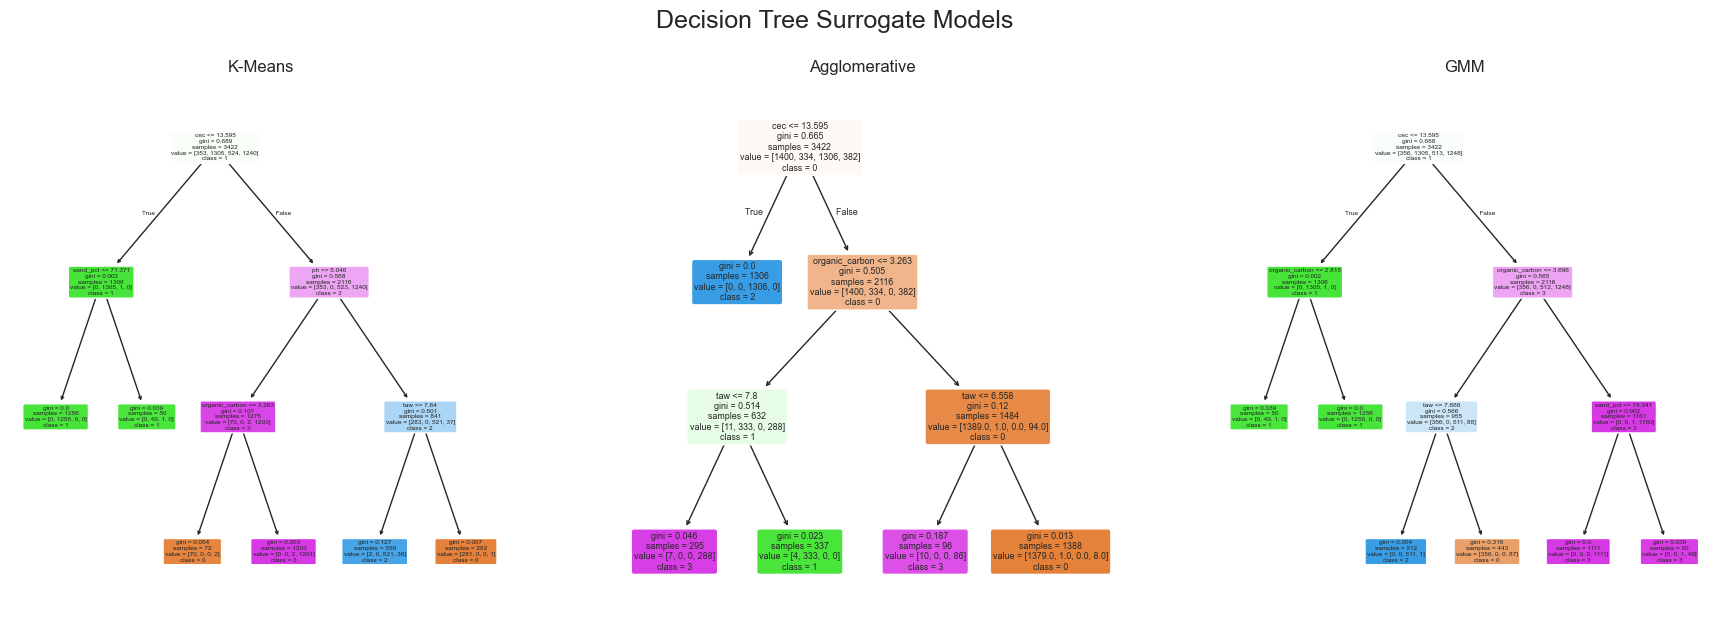

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (model, dt) in zip(axes, surrogates.items()):
    plot_tree(
        dt,
        feature_names=FEATURES,
        class_names=[str(i) for i in sorted(df[CLUSTER_MODELS[model]].unique())],
        filled=True,
        rounded=True,
        ax=ax
    )
    ax.set_title(model)

plt.suptitle("Decision Tree Surrogate Models", fontsize=18)
plt.show()

#### **Rule Extraction**

In [21]:
for model, dt in surrogates.items():
    print("\n" + "="*70)
    print(f"{model} - Decision Rules")
    print("="*70)
    print(export_text(dt, feature_names=FEATURES))


K-Means - Decision Rules
|--- cec <= 13.59
|   |--- sand_pct <= 71.37
|   |   |--- class: 1
|   |--- sand_pct >  71.37
|   |   |--- class: 1
|--- cec >  13.59
|   |--- ph <= 5.05
|   |   |--- organic_carbon <= 3.28
|   |   |   |--- class: 0
|   |   |--- organic_carbon >  3.28
|   |   |   |--- class: 3
|   |--- ph >  5.05
|   |   |--- taw <= 7.64
|   |   |   |--- class: 2
|   |   |--- taw >  7.64
|   |   |   |--- class: 0


Agglomerative - Decision Rules
|--- cec <= 13.59
|   |--- class: 2
|--- cec >  13.59
|   |--- organic_carbon <= 3.26
|   |   |--- taw <= 7.80
|   |   |   |--- class: 3
|   |   |--- taw >  7.80
|   |   |   |--- class: 1
|   |--- organic_carbon >  3.26
|   |   |--- taw <= 6.56
|   |   |   |--- class: 3
|   |   |--- taw >  6.56
|   |   |   |--- class: 0


GMM - Decision Rules
|--- cec <= 13.59
|   |--- organic_carbon <= 2.82
|   |   |--- class: 1
|   |--- organic_carbon >  2.82
|   |   |--- class: 1
|--- cec >  13.59
|   |--- organic_carbon <= 3.70
|   |   |--- taw <= 

#### **Validation Curves**

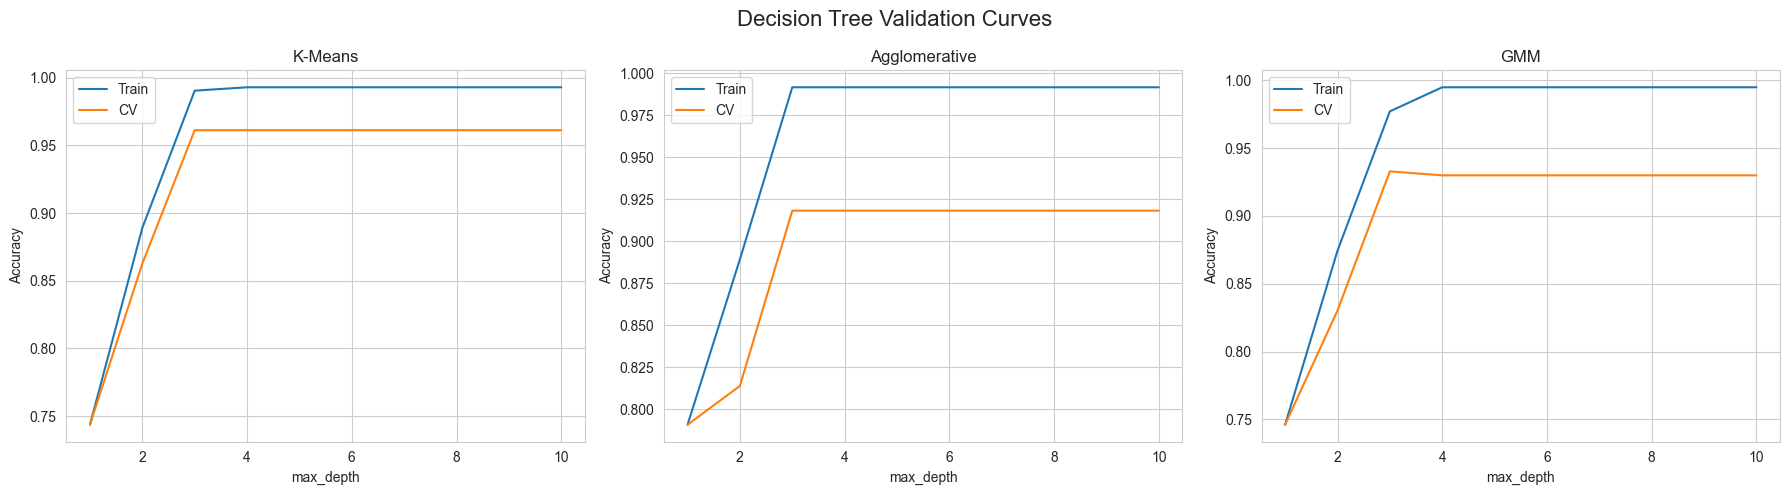

In [22]:
param_range = range(1, 11)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model, col) in zip(axes, CLUSTER_MODELS.items()):
    X = df[FEATURES]
    y = df[col]

    train_scores, test_scores = validation_curve(
        DecisionTreeClassifier(min_samples_leaf=50, random_state=42),
        X, y,
        param_name="max_depth",
        param_range=param_range,
        cv=5,
        scoring="accuracy"
    )

    ax.plot(param_range, train_scores.mean(axis=1), label="Train")
    ax.plot(param_range, test_scores.mean(axis=1), label="CV")
    ax.set_title(model)
    ax.set_xlabel("max_depth")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle("Decision Tree Validation Curves", fontsize=16)
plt.tight_layout()
plt.show()

#### **Learning Curves**

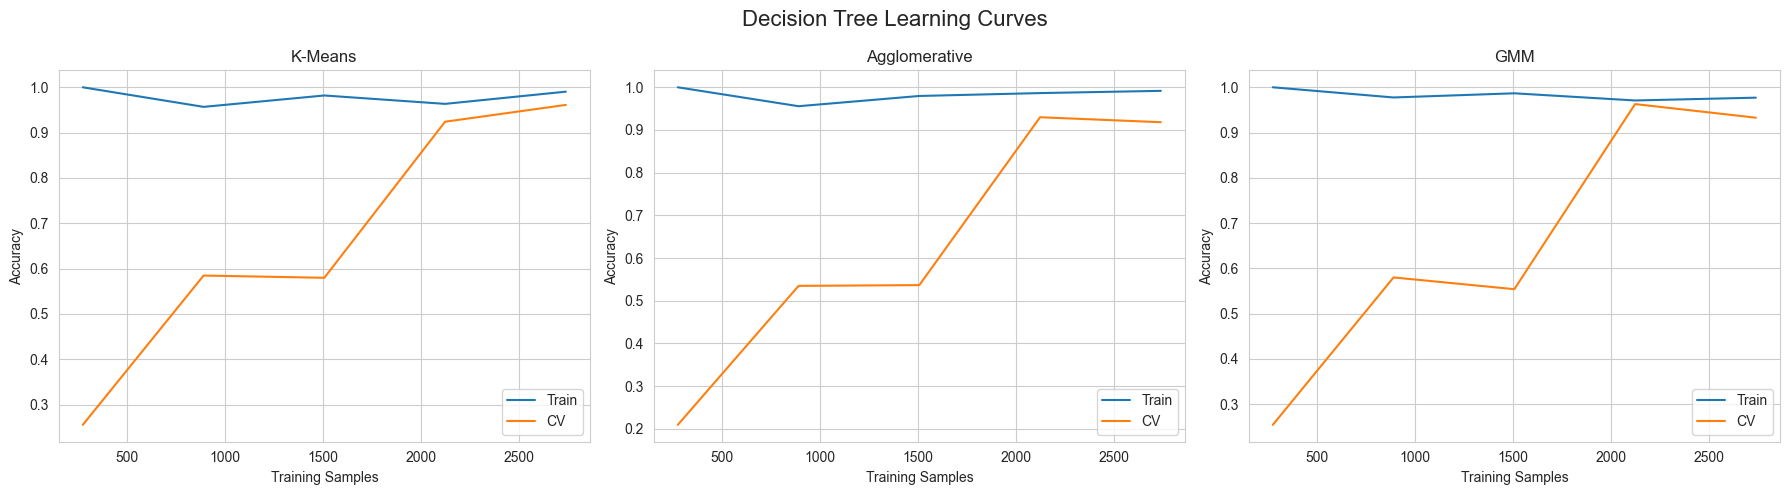

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model, col) in zip(axes, CLUSTER_MODELS.items()):
    X = df[FEATURES]
    y = df[col]

    train_sizes, train_scores, test_scores = learning_curve(
        DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=42),
        X, y,
        cv=5,
        scoring="accuracy"
    )

    ax.plot(train_sizes, train_scores.mean(axis=1), label="Train")
    ax.plot(train_sizes, test_scores.mean(axis=1), label="CV")
    ax.set_title(model)
    ax.set_xlabel("Training Samples")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle("Decision Tree Learning Curves", fontsize=16)
plt.tight_layout()
plt.show()

### **6. Random Forest**

#### **Train Surrogates**

In [24]:
rf_models = {}
rf_fidelities = {}

for model, col in CLUSTER_MODELS.items():
    X_feat = df[FEATURES]
    y = df[col]

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=20,
        random_state=42
    )
    rf.fit(X_feat, y)
    rf_models[model] = rf

    train_acc = accuracy_score(y, rf.predict(X_feat))
    cv_acc    = cross_val_score(rf, X_feat, y, cv=5, scoring="accuracy").mean()
    rf_fidelities[model] = {"train": round(train_acc, 3), "cv": round(cv_acc, 3)}

    print(f"{model} RF - Train: {train_acc:.3f}, CV: {cv_acc:.3f}")

K-Means RF - Train: 0.996, CV: 0.968
Agglomerative RF - Train: 0.999, CV: 0.941
GMM RF - Train: 1.000, CV: 0.961


#### **Validation Curves**

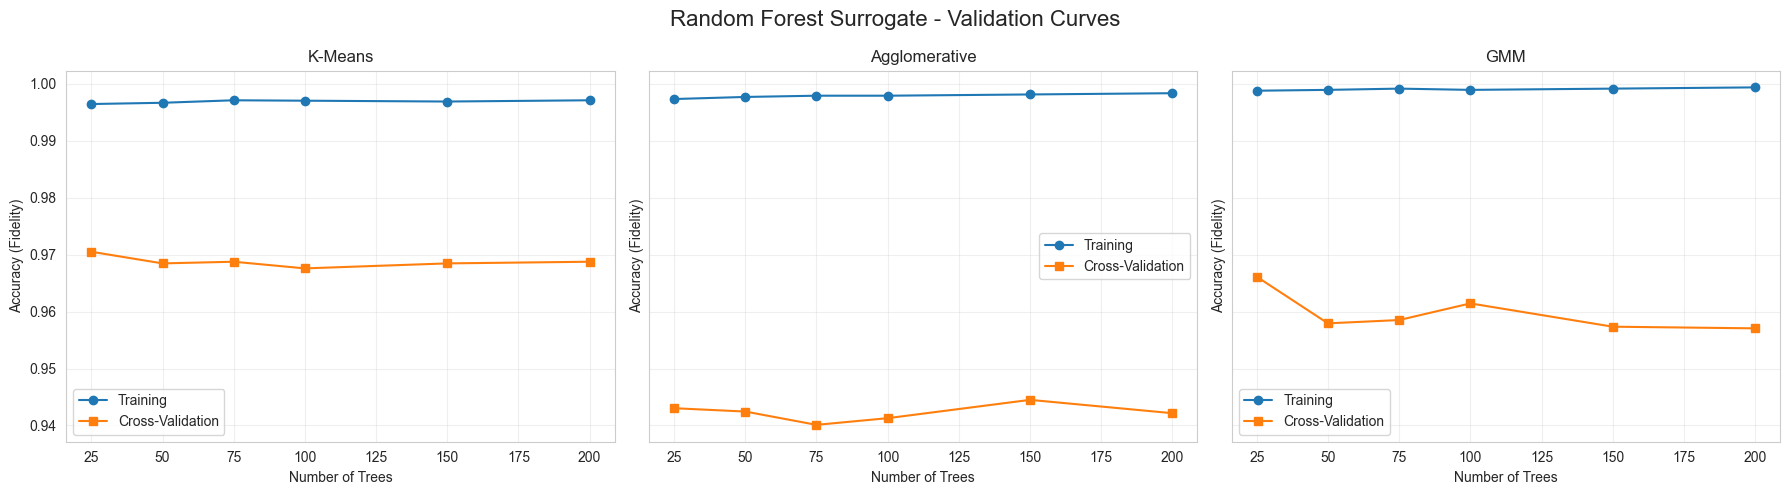

In [25]:
from sklearn.model_selection import validation_curve

param_range_rf = [25, 50, 75, 100, 150, 200]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (model, col) in zip(axes, CLUSTER_MODELS.items()):
    X = df[FEATURES]
    y = df[col]

    train_scores, test_scores = validation_curve(
        RandomForestClassifier(
            max_depth=10,
            min_samples_leaf=20,
            random_state=42
        ),
        X, y,
        param_name="n_estimators",
        param_range=param_range_rf,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    ax.plot(
        param_range_rf,
        train_scores.mean(axis=1),
        marker="o",
        label="Training"
    )
    ax.plot(
        param_range_rf,
        test_scores.mean(axis=1),
        marker="s",
        label="Cross-Validation"
    )

    ax.set_title(model)
    ax.set_xlabel("Number of Trees")
    ax.set_ylabel("Accuracy (Fidelity)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Random Forest Surrogate - Validation Curves",
    fontsize=16
)
plt.tight_layout()
plt.show()

#### **Learning Curves**

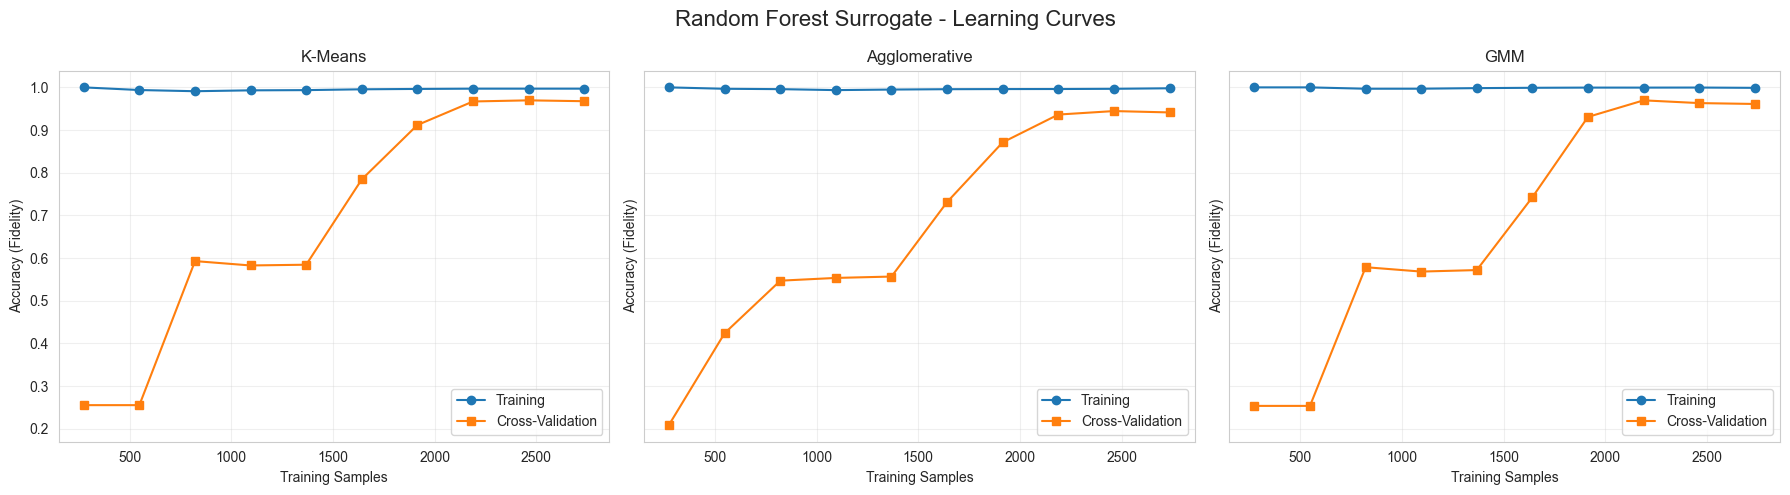

In [26]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (model, col) in zip(axes, CLUSTER_MODELS.items()):
    X = df[FEATURES]
    y = df[col]

    train_sizes, train_scores, test_scores = learning_curve(
        RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_leaf=20,
            random_state=42
        ),
        X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    ax.plot(
        train_sizes,
        train_scores.mean(axis=1),
        marker="o",
        label="Training"
    )
    ax.plot(
        train_sizes,
        test_scores.mean(axis=1),
        marker="s",
        label="Cross-Validation"
    )

    ax.set_title(model)
    ax.set_xlabel("Training Samples")
    ax.set_ylabel("Accuracy (Fidelity)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Random Forest Surrogate - Learning Curves",
    fontsize=16
)
plt.tight_layout()
plt.show()

### **7. Surrogate Model Analysis**

Since clustering models are difficult to interpret directly, two simpler models, a Decision Tree and a Random Forest, were trained to mimic their behavior. Both surrogate models were evaluated using validation curves and learning curves. All accuracy figures below are **5-fold cross-validation accuracy**, which reflects true generalisation performance rather than in sample training accuracy.



#### **Validation Curves**

| **Surrogate** | **Setting Tested** | **K-Means** | **Agglomerative** | **GMM** |
|:----------|:--------------|:--------|:--------------|:----|
| **Decision Tree** | Max Depth | Accuracy improved up to depth 3 (CV ~96%, Train ~99%) and plateaued beyond that | Accuracy improved up to depth 3 (CV ~92%, Train ~99%) and plateaued beyond that | Accuracy improved up to depth 3 (CV ~93%, Train ~99%) and plateaued beyond that |
| **Random Forest** | Number of Trees | Train steady near 1.0. CV fluctuated near 0.97, highest at 25 trees (~0.97) | Train steady near 1.0. CV fluctuated near 0.945, highest at 100 trees (~0.945) | Train steady near 1.0. CV fluctuated near 0.96, highest at 25 trees (~0.97) |

**Key Findings:**
- For the Decision Tree, a depth of 3 is sufficient for all three clustering methods and deeper trees only memorize training data without improving generalization
- For the Random Forest, as few as 25 trees are enough for K-Means and GMM, while Agglomerative needed 100 trees to reach its best performance
- Both surrogates show a consistent train/CV gap across all clustering methods, meaning the remaining error comes from label complexity, not model limitations



#### **Learning Curves**

| **Surrogate** | **K-Means** | **Agglomerative** | **GMM** |
|:----------|:--------|:--------------|:----|
| **Decision Tree** | Train fluctuated between 0.9 and 1.0. CV improved steadily and after 2000 samples came very close to train and continued improving with a very small gap | Train fluctuated between 0.9 and 1.0. CV improved steadily and after 2000 samples came very close to train, then slightly decreased but stayed above 0.9 | Train fluctuated between 0.9 and 1.0. CV improved steadily and after 2000 samples came very close to train, then slightly decreased but stayed above 0.9 |
| **Random Forest** | Train steady near 1.0. CV improved steadily and after 2000 samples came very close to train and remained stable | Train steady near 1.0. CV improved steadily and after 2000 samples came very close to train and remained stable | Train steady near 1.0. CV improved steadily and after 2000 samples came very close to train and remained stable |

**Key Findings:**
- Both surrogates require approximately 2000+ samples to generalize well regardless of clustering method
- The Random Forest showed more stable training behavior than the Decision Tree where train accuracy was steady near 1.0 for Random Forest but fluctuated between 0.9 and 1.0 for the Decision Tree
- The Random Forest learning curves were also more stable after 2000 samples and CV remained steady for all three methods, while the Decision Tree showed slight CV decrease for Agglomerative and GMM
- K-Means produced the most stable CV learning behavior across both surrogate models



#### **Overall Surrogate Performance Summary**

| **Aspect** | **Decision Tree** | **Random Forest** | 
|:-------|:-------------|:--------------|
| **K-Means CV Accuracy** | ~96% | ~97% |
| **GMM CV Accuracy** | ~93% | ~96% |
| **Agglomerative CV Accuracy** | ~92% | ~94.5% | 
| **Sensitivity to Settings** | High, depth must be tuned | Low, stable across tree counts |
| **Overfitting Risk** | Moderate | Low |
| **Data Requirement** | ~2000+ samples | ~2000+ samples |
| **Train Accuracy Stability** | Fluctuates between 0.9 and 1.0 | Steady near 1.0 throughout |
| **CV Stability After 2000 Samples** | Slight decrease for Agglomerative & GMM | Stable for all three methods |
| **Overall Recommendation** | Good baseline surrogate | More robust and preferred choice |


#### **Key Takeaways**

| **Finding** | **Detail** |
|:--------|:-------|
| **Optimal settings** | Decision Tree depth of 3 and Random Forest with 25-100 trees are sufficient for all clustering methods |
| **Main bottleneck** | Training data size - both surrogates needed ~2000+ samples to generalize well |
| **Best surrogate** | Random Forest - consistently more accurate, more stable in both training and CV behavior, and requires less tuning |
| **Easiest to learn** | K-Means - highest CV accuracy and most stable learning behavior across both surrogates |
| **Hardest to learn** | Agglomerative - lowest CV accuracy across both surrogates and required more trees to reach peak RF performance |

### **8. SHAP**

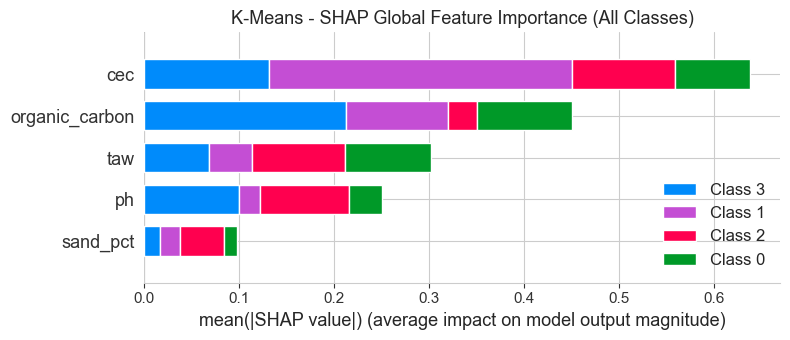

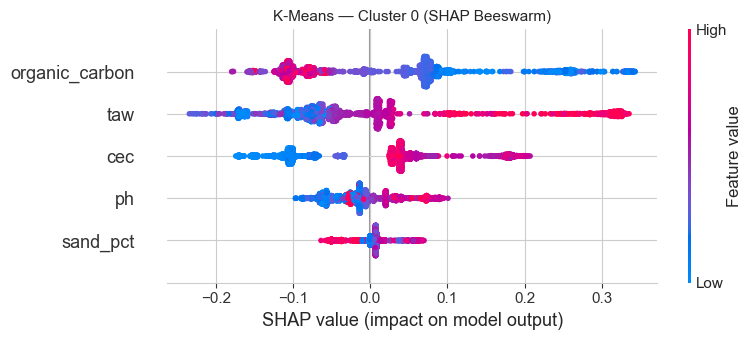

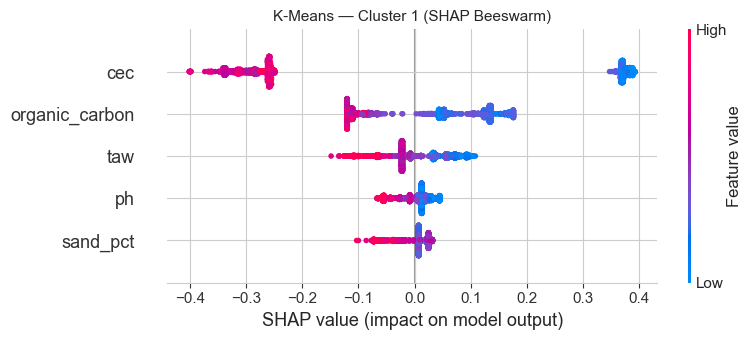

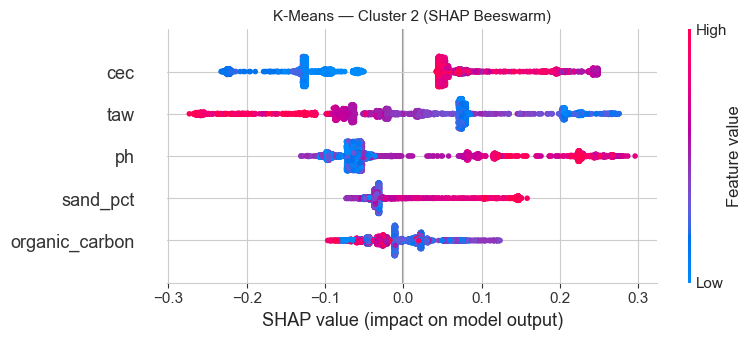

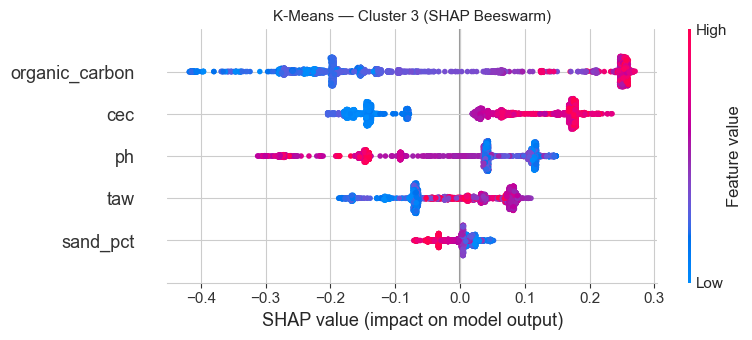

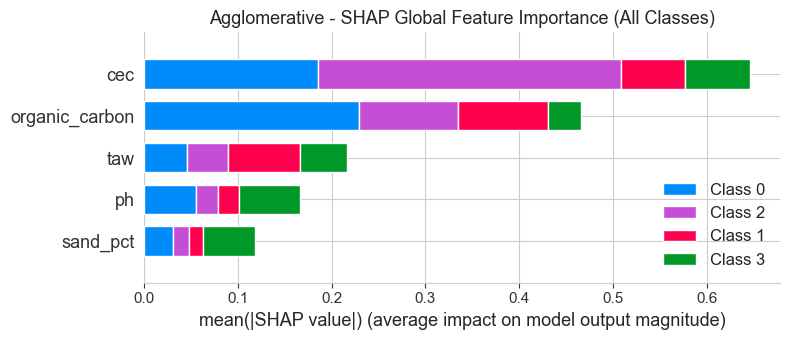

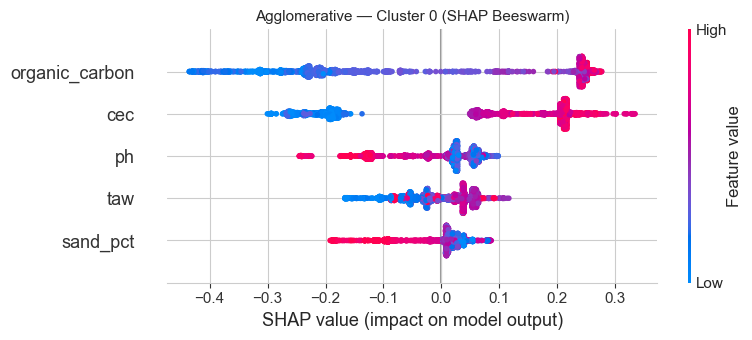

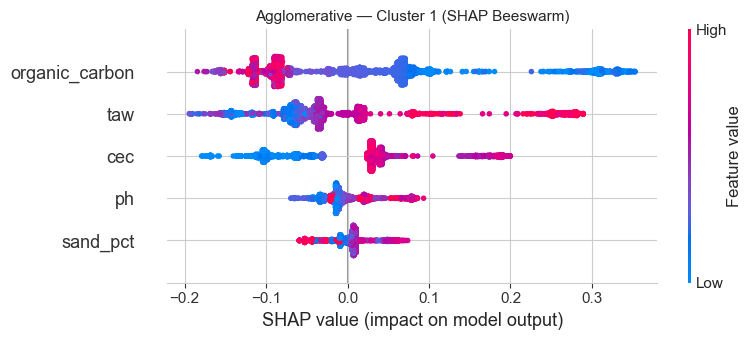

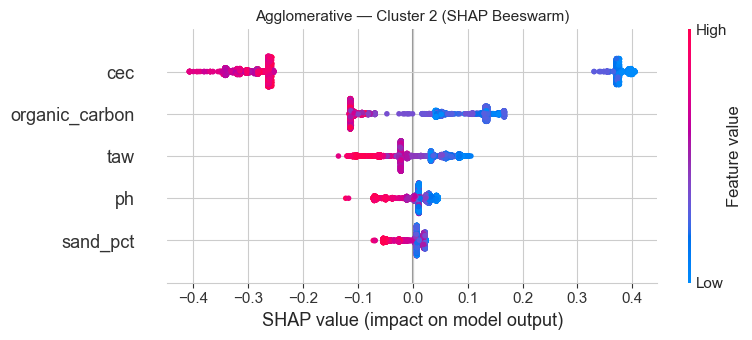

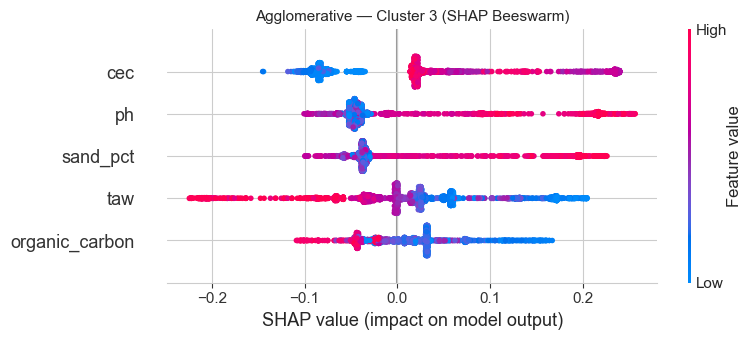

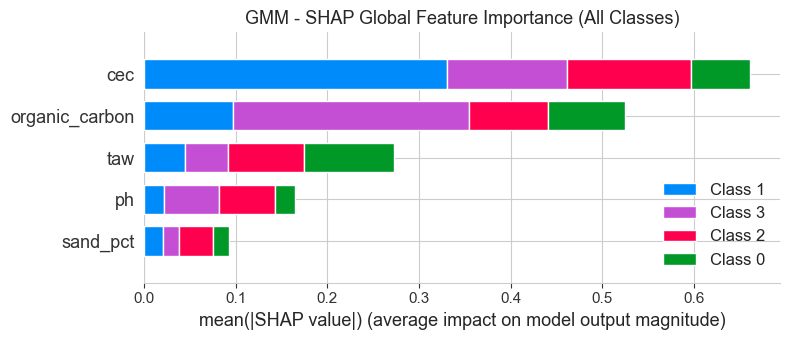

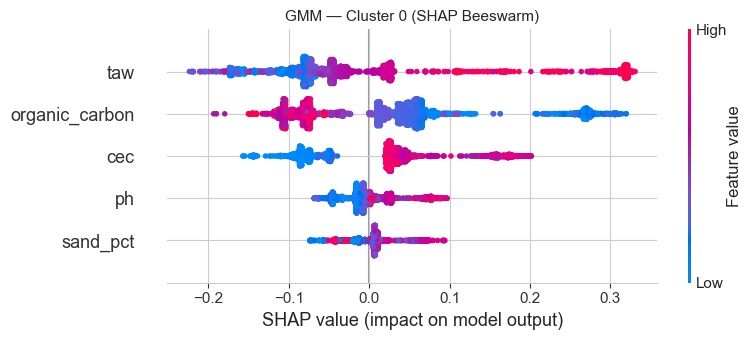

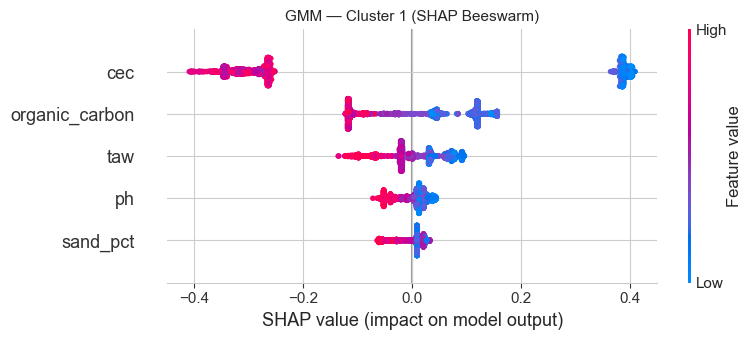

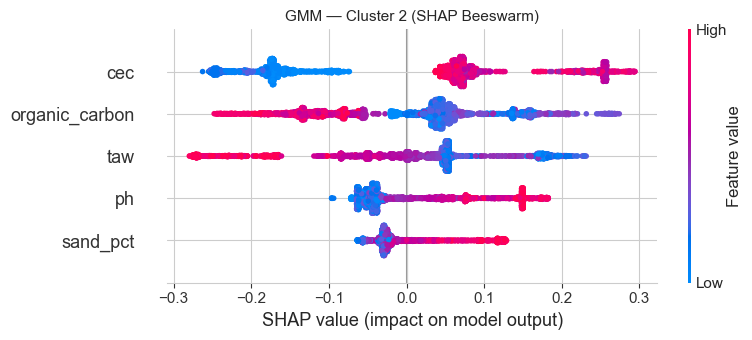

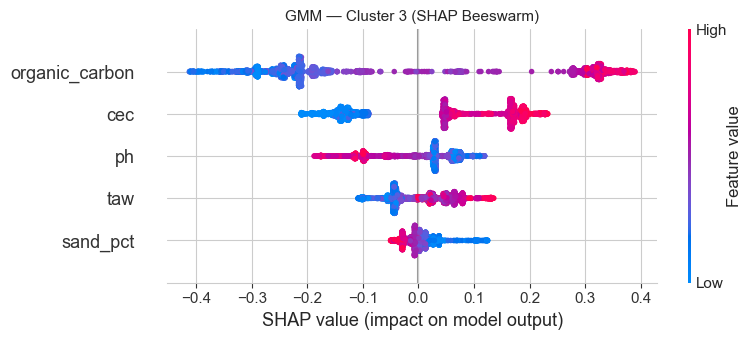

SHAP export complete.


In [29]:
X = df[FEATURES]
shap_data = {}

for model_name, rf in rf_models.items():
    explainer = shap.TreeExplainer(rf)
    shap_values_raw = explainer.shap_values(X)

    if isinstance(shap_values_raw, list):
        shap_values_3d = np.stack(shap_values_raw, axis=2)
    else:
        shap_values_3d = shap_values_raw  

    # Bar plot - feature importance magnitude
    plt.figure(figsize=(6, 4))
    shap.summary_plot(
        shap_values_raw if isinstance(shap_values_raw, list) else shap_values_3d,
        X,
        plot_type="bar",
        show=False
    )
    plt.title(f"{model_name} - SHAP Global Feature Importance (All Classes)", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Beeswarm plots - feature importance direction per class
    cluster_col = CLUSTER_MODELS[model_name]
    class_names = [f"Cluster {i}" for i in sorted(df[cluster_col].unique())]
    n_classes = shap_values_3d.shape[2]

    for cls_idx in range(n_classes):
        plt.figure(figsize=(7, 4))
        shap.summary_plot(
            shap_values_3d[:, :, cls_idx],
            X,
            plot_type="dot",
            show=False
        )
        plt.title(f"{model_name} — {class_names[cls_idx]} (SHAP Beeswarm)", fontsize=11)
        plt.tight_layout()
        plt.show()

    # Average absolute SHAP across all classes
    shap_abs = np.abs(shap_values_3d).mean(axis=2)

    global_importance = shap_abs.mean(axis=0)

    shap_data[model_name] = {
        "global": {
            f: float(round(v, 4))
            for f, v in zip(FEATURES, global_importance)
        },
        "clusters": {}
    }

    # Cluster-wise SHAP
    cluster_col = CLUSTER_MODELS[model_name]

    for cluster_id in sorted(df[cluster_col].unique()):
        idx = df[cluster_col] == cluster_id
        cluster_shap = shap_abs[idx]
        cluster_importance = cluster_shap.mean(axis=0)

        shap_data[model_name]["clusters"][str(cluster_id)] = {
            f: float(round(v, 4))
            for f, v in zip(FEATURES, cluster_importance)
        }

with open("../outputs/web_shap.json", "w") as f:
    json.dump(shap_data, f, indent=2)

print("SHAP export complete.")

In [28]:
# Feature means per cluster
for model, col in CLUSTER_MODELS.items():
    print("=" * 60)
    print(f"MODEL: {model}")
    print("=" * 60)

    display(
        df.groupby(col)[FEATURES]
        .mean()
        .round(3)
    )

MODEL: K-Means


,taw,organic_carbon,cec,ph,sand_pct
cluster_kmeans,,,,,
0,8.825,2.906,16.640,5.189,70.328
1,6.895,3.179,9.769,4.864,66.271
2,6.627,3.311,17.196,5.343,78.758
3,7.792,4.107,18.651,4.810,62.407


MODEL: Agglomerative


,taw,organic_carbon,cec,ph,sand_pct
cluster_agg,,,,,
0,7.712,4.057,18.651,4.846,63.543
1,8.828,2.886,16.666,5.204,70.837
2,6.895,3.179,9.770,4.864,66.281
3,6.539,3.158,16.552,5.414,80.578


MODEL: GMM


,taw,organic_carbon,cec,ph,sand_pct
cluster_gmm,,,,,
0,8.828,2.918,16.664,5.180,70.278
1,6.895,3.180,9.769,4.863,66.280
2,6.653,3.230,17.064,5.343,78.129
3,7.768,4.131,18.691,4.816,62.796


### **9. Moran's I - Spatial Autocorrelation of Cluster Labels**

In [36]:
from libpysal.weights import KNN
from esda.moran import Moran

w = KNN.from_array(df[["lon", "lat"]].values, k=8)
w.transform = "R"

print("Moran's I - Spatial Autocorrelation of Cluster Labels\n")
print(f"{'Model':<20} {'Moran I':>9}  {'p-value':>9}")
print("-" * 70)

for model_name, cluster_col in CLUSTER_MODELS.items():
    moran = Moran(df[cluster_col].astype(float), w)
    if moran.p_sim < 0.001:
        sig = "p < 0.001 (highly significant)"
    else:
        sig = f"p = {moran.p_sim:.3f}"
    print(f"{model_name:<20} {moran.I:>9.4f}  {sig}")

Moran's I - Spatial Autocorrelation of Cluster Labels

Model                  Moran I    p-value
----------------------------------------------------------------------
K-Means                 0.9446  p = 0.001
Agglomerative           0.9539  p = 0.001
GMM                     0.9531  p = 0.001


### **Spatial Autocorrelation Assessment**

All three models have very high Moran’s I values (above 0.94).  
This means that nearby pixels usually belong to the same cluster.

This is normal for soil data because soil properties change slowly across space, not suddenly from one pixel to another.

However, this high spatial similarity affects how the results should be interpreted:

- **Silhouette, Calinski-Harabasz, Davies-Bouldin:**  
  These metrics assume that all pixels are independent.  
  In reality, many neighbouring pixels are almost identical, so the true number of independent samples is much smaller than 3,422.  
  As a result, these scores appear more optimistic than they actually are.

- **Surrogate model cross-validation accuracy:**  
  Random data splitting causes nearby pixels to appear in both training and validation sets.  
  This inflates accuracy, and real performance on completely unseen areas would likely be lower.

- **AIC/BIC for GMM:**  
  The continuous decrease in AIC and BIC happens because spatial autocorrelation reduces the effective sample size.  
  This leads to insufficient penalization of model complexity.

Therefore, all numerical metrics should be treated as indicative rather than exact, and agreement across different clustering methods provides stronger validation than any single metric value.